# Larmor Precession

Lecturer: **Yi-Te Huang**

---

A spin-$\frac{1}{2}$ magnetic moment placed in a magnetic field precesses around the field axis. This is one of the simplest examples of quantum dynamics, and a great first step for understanding the time-evolution solvers in `QuantumToolbox.jl`.

## Table of Content

- Physical background
- Static field: `sesolve`
- Precession with relaxation: `mesolve`
- Precession around a general axis
- Time-dependent field: `QobjEvo`

In [1]:
using QuantumToolbox
using Random, CairoMakie

## Physical background

Consider a spin-$\frac{1}{2}$ with magnetic dipole moment $\vec{\mu} = \frac{\gamma}{2} \vec{\sigma}$, where $\gamma$ is called the gyromagnetic ratio. When a magnetic dipole is placed in a magnetic field $\vec{B} = B_0\hat{z}$, it experiences a torque, $\vec{\mu} \times \vec{B}$, which tends to line it up parallel to the field. The Hamiltonian (energy) associated with this torque is given by ($\hbar=1$)

```math
\hat{H} = -\vec{\mu} \cdot \vec{B} = -\frac{\gamma}{2} \vec{\sigma} \cdot \vec{B} = -\frac{\gamma B_0}{2}\hat{\sigma}_z = -\frac{\omega_0}{2}\hat{\sigma}_z,
```

where $\omega_0 = \gamma B_0$ is the **Larmor frequency**.

Solving the Heisenberg equations of motion for $\langle\hat{\sigma}_x(t)\rangle$, $\langle\hat{\sigma}_y(t)\rangle$, and $\langle\hat{\sigma}_z(t)\rangle$ shows that the transverse components rotate into each other at angular frequency $\omega_0$, while the longitudinal component is conserved:

```math
\begin{align}
\langle\hat{\sigma}_x(t)\rangle &= \langle\hat{\sigma}_x(0)\rangle\cos(\omega_0 t) + \langle\hat{\sigma}_y(0)\rangle\sin(\omega_0 t)\notag\\
\langle\hat{\sigma}_y(t)\rangle &= \langle\hat{\sigma}_y(0)\rangle\cos(\omega_0 t) - \langle\hat{\sigma}_x(0)\rangle\sin(\omega_0 t)\notag\\
\langle\hat{\sigma}_z(t)\rangle &= \langle\hat{\sigma}_z(0)\rangle\notag
\end{align}
```

We now reproduce this behavior numerically, first with `sesolve`, then extend it to a time-dependent field with `QobjEvo`, and finally add dissipation with `mesolve`.


## Static field: `sesolve`

We consider an initial state that is *not* aligned with the field ($Z$-axis), so that the precession is visible. Starting from a random initial state generated by `rand_ket(2)`:

In [2]:
# Pauli matrices
σx = sigmax()
σy = sigmay()
σz = sigmaz()
e_ops = [σx, σy, σz] # observables (for calculating expectation values)

ψ0 = rand_ket(2, rng = MersenneTwister(160)) # random initial state 


Quantum Object:   type=Ket()   dims=([2], [1])   size=(2,)
2-element Vector{ComplexF64}:
   0.4194589116378117 - 0.6066947891294618im
 -0.10725344181229311 - 0.6666875981373863im

We first check the initial conditions by computing the expectation values of the three Pauli operators for $|\psi_0\rangle$: these values give the spin component along each axis before we let it evolve.

In [3]:
@show real(expect(σx, ψ0))
@show real(expect(σy, ψ0))
@show real(expect(σz, ψ0));

real(expect(σx, ψ0)) = 0.7189749595903904
real(expect(σy, ψ0)) = -0.6894363171617061
real(expect(σz, ψ0)) = 0.08804869141843963


`sesolve` propagates a pure state $|\psi(t)\rangle$ by directly integrating the Schrödinger equation

```math
i\frac{d}{dt}|\psi(t)\rangle = \hat{H}(t)|\psi(t)\rangle
```

for a (possibly time-dependent) Hamiltonian $\hat{H}(t)$.

In [4]:
ω0 =  1.0           # Larmor frequency
H  = -0.5 * ω0 * σz # Hamiltonian

tlist = range(0, 30, 400)
sol_se = sesolve(H, ψ0, tlist; e_ops = e_ops)

[sesolve] 100%|███████████████████████████| Time: 0:00:00 (25.83 μs/it)


Solution of time evolution
(return code: Success)
--------------------------
num_states = 1
num_expect = 3
ODE alg.: OrdinaryDiffEqVerner.Vern7{typeof(OrdinaryDiffEqCore.trivial_limiter!), typeof(OrdinaryDiffEqCore.trivial_limiter!), FastBroadcast.Serial, Bool}(OrdinaryDiffEqCore.trivial_limiter!, OrdinaryDiffEqCore.trivial_limiter!, FastBroadcast.Serial(), false)
abstol = 1.0e-8
reltol = 1.0e-6


`sesolve` returns a `TimeEvolutionSol`, which is a structure storing the results and some information from solving time evolution.

`sol.expect` holds the expectation values of `e_ops` at every time in `tlist`, one row per operator. Let's plot $\langle\hat{\sigma}_x\rangle$, $\langle\hat{\sigma}_y\rangle$, and $\langle\hat{\sigma}_z\rangle$ against time:

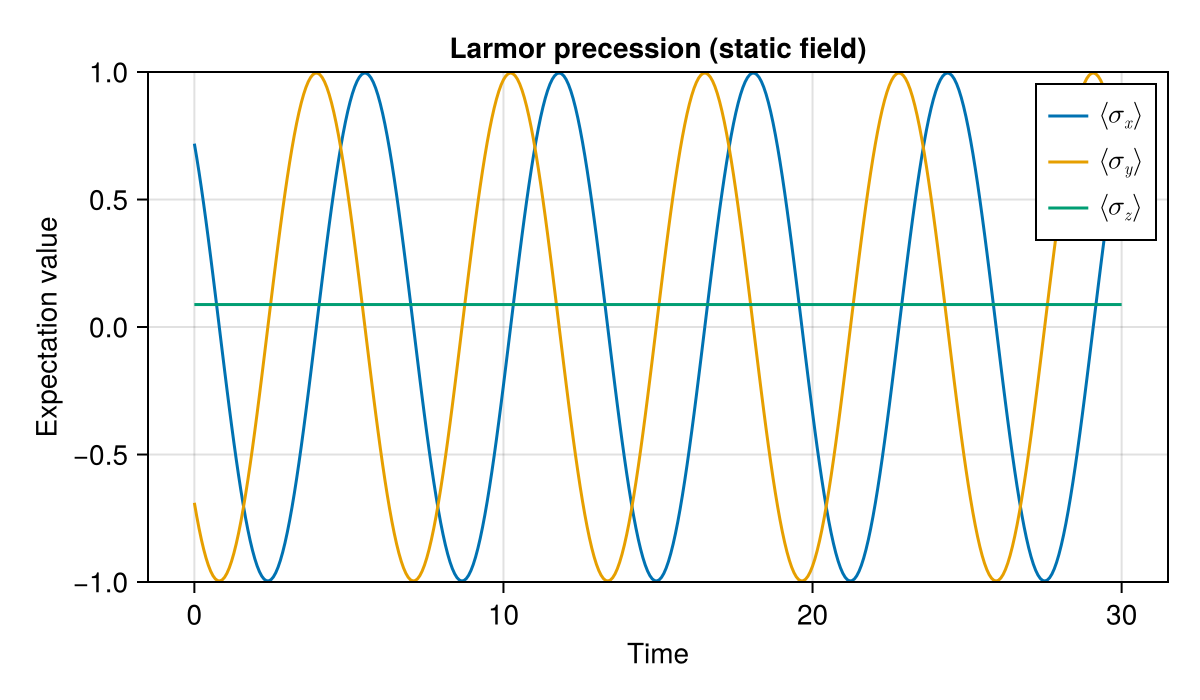

In [5]:
fig = Figure(size = (600, 350))
ax = Axis(
    fig[1, 1],
    xlabel = "Time",
    ylabel = "Expectation value",
    title = "Larmor precession (static field)",
    limits = (nothing, nothing, -1, 1),
)

lines!(ax, tlist, real(sol_se.expect[1, :]), label = L"\langle\sigma_x\rangle")
lines!(ax, tlist, real(sol_se.expect[2, :]), label = L"\langle\sigma_y\rangle")
lines!(ax, tlist, real(sol_se.expect[3, :]), label = L"\langle\sigma_z\rangle")
axislegend(ax, position = :rt)

fig

As expected, $\langle\hat{\sigma}_x\rangle$ and $\langle\hat{\sigma}_y\rangle$ oscillate at the Larmor frequency $\omega_0$ while $\langle\hat{\sigma}_z\rangle$ stays constant. Plotting on the Bloch sphere makes the precession even clearer. `QuantumToolbox` also provides visualization functions built on top of `Makie`, so you can inspect a state without manually writing plotting code.

For more details about the `Bloch`-sphere visualization, see our documentation: https://qutip.org/QuantumToolbox.jl/stable/users_guide/plotting_the_bloch_sphere

┌ Warning: Arrows3D{Tuple{Vector{Point{3, Float32}}, Vector{Point{3, Float32}}}} is not supported by cairo right now
└ @ CairoMakie /opt/julia/packages/CairoMakie/M4iiC/src/plot-primitives.jl:191
┌ Warning: Arrows3D{Tuple{Vector{Point{3, Float32}}, Vector{Point{3, Float32}}}} is not supported by cairo right now
└ @ CairoMakie /opt/julia/packages/CairoMakie/M4iiC/src/plot-primitives.jl:191


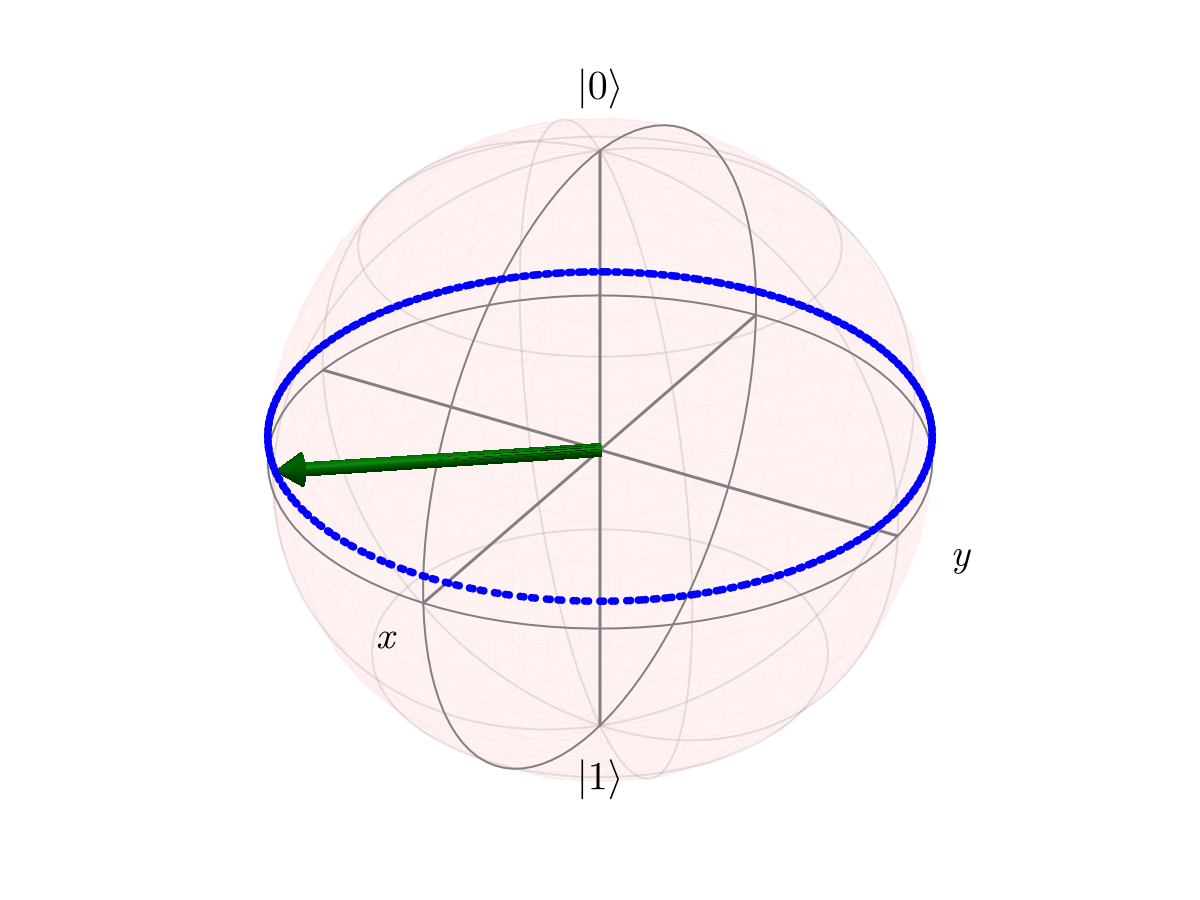

In [6]:
b_se = Bloch() # create an empty Bloch sphere

add_states!(b_se, ψ0) # initial state (arrow)
add_points!(b_se, [real(sol_se.expect[1, :]), real(sol_se.expect[2, :]), real(sol_se.expect[3, :])])

# render and show Bloch sphere
fig, _ = render(b_se)
fig

It traces a circle at fixed latitude, set by the initial $\langle\hat{\sigma}_z(0)\rangle$. Note that the green arrow indicates the initial state.

## Precession with relaxation: `mesolve`

A real spin is never perfectly isolated from its environment. Two relaxation processes are commonly distinguished:

- **Energy relaxation**: the spin exchanges energy with its environment and relaxes toward the ground state, described by the lowering operator $\hat{\sigma}_-$ with decay rate $\gamma_e$.
- **Pure dephasing**: random fluctuations of the field randomize the phase of the transverse components without changing the populations, described by $\hat{\sigma}_z$ with rate $\gamma_\varphi$.

Once the spin is coupled to an environment, the state in general evolves into a mixed state (requiring a density-matrix representation), and `mesolve` integrates the Lindblad master equation

```math
\frac{d\hat{\rho}}{dt} = -i\left[\hat{H},\hat{\rho}\right] + \sum_k \left(\hat{C}_k\hat{\rho}\hat{C}_k^\dagger - \frac{1}{2}\left\{\hat{C}_k^\dagger\hat{C}_k,\hat{\rho}\right\}\right),
```

where the $\hat{C}_k$ are the collapse operators (here $\sqrt{\gamma_e}\hat{\sigma}_-$ and $\sqrt{\gamma_\varphi}\hat{\sigma}_z$) and $\{\cdot,\cdot\}$ denotes the anticommutator. The first term is the same unitary evolution as in `sesolve`; the summation characterizes the dissipation process (relaxation and dephasing in this example).

In [7]:
γe = 0.1   # energy relaxation rate
γϕ = 0.05  # pure   dephasing  rate

c_ops = [sqrt(γe) * sigmam(), sqrt(γϕ) * σz]
sol_me = mesolve(H, ψ0, tlist, c_ops; e_ops = e_ops)

[mesolve] 100%|███████████████████████████| Time: 0:00:00 ( 0.71 μs/it)


Solution of time evolution
(return code: Success)
--------------------------
num_states = 1
num_expect = 3
ODE alg.: OrdinaryDiffEqLowOrderRK.DP5{typeof(OrdinaryDiffEqCore.trivial_limiter!), typeof(OrdinaryDiffEqCore.trivial_limiter!), FastBroadcast.Serial}(OrdinaryDiffEqCore.trivial_limiter!, OrdinaryDiffEqCore.trivial_limiter!, FastBroadcast.Serial())
abstol = 1.0e-8
reltol = 1.0e-6


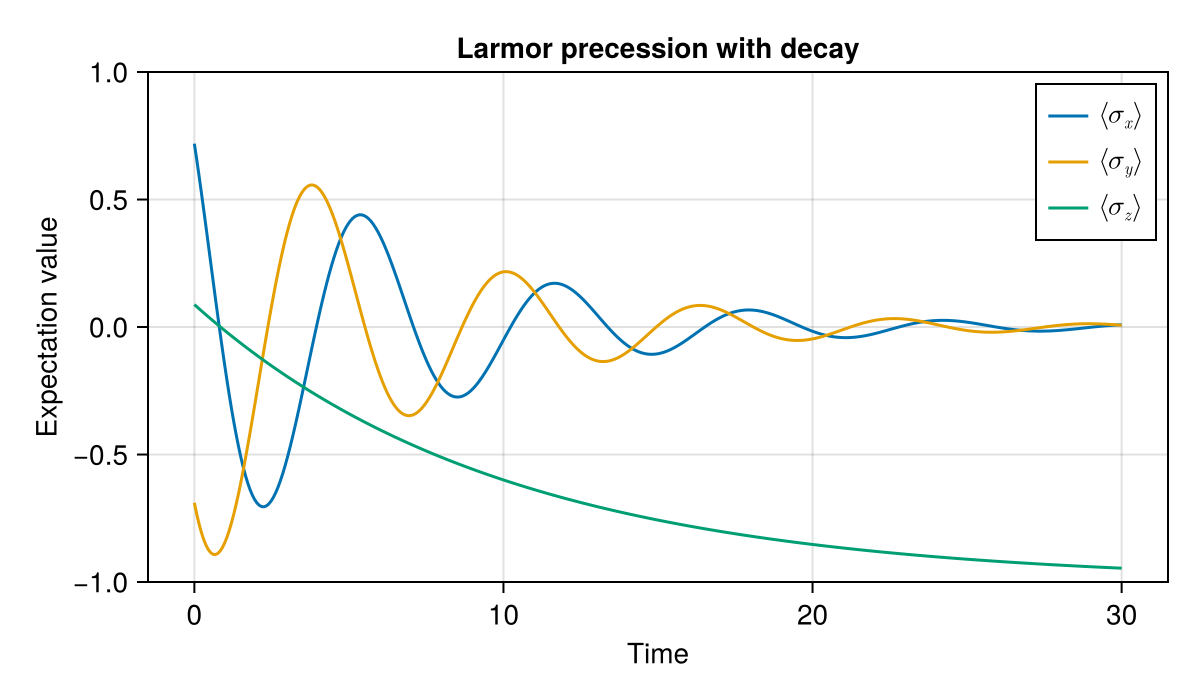

In [8]:
fig = Figure(size = (600, 350))
ax = Axis(
    fig[1, 1],
    xlabel = "Time",
    ylabel = "Expectation value",
    title = "Larmor precession with decay",
    limits = (nothing, nothing, -1, 1),
)

lines!(ax, tlist, real(sol_me.expect[1, :]), label = L"\langle\sigma_x\rangle")
lines!(ax, tlist, real(sol_me.expect[2, :]), label = L"\langle\sigma_y\rangle")
lines!(ax, tlist, real(sol_me.expect[3, :]), label = L"\langle\sigma_z\rangle")
axislegend(ax, position = :rt)

fig

The transverse components now decay as they precess, and $\langle\hat{\sigma}_z(t)\rangle$ decays from its initial value toward $-1$. On the Bloch sphere, instead of a closed latitude circle, the Bloch vector now spirals down from its initial latitude toward the south pole. Plotting both trajectories together shows the effect of decay directly:

┌ Warning: Arrows3D{Tuple{Vector{Point{3, Float32}}, Vector{Point{3, Float32}}}} is not supported by cairo right now
└ @ CairoMakie /opt/julia/packages/CairoMakie/M4iiC/src/plot-primitives.jl:191
┌ Warning: Arrows3D{Tuple{Vector{Point{3, Float32}}, Vector{Point{3, Float32}}}} is not supported by cairo right now
└ @ CairoMakie /opt/julia/packages/CairoMakie/M4iiC/src/plot-primitives.jl:191


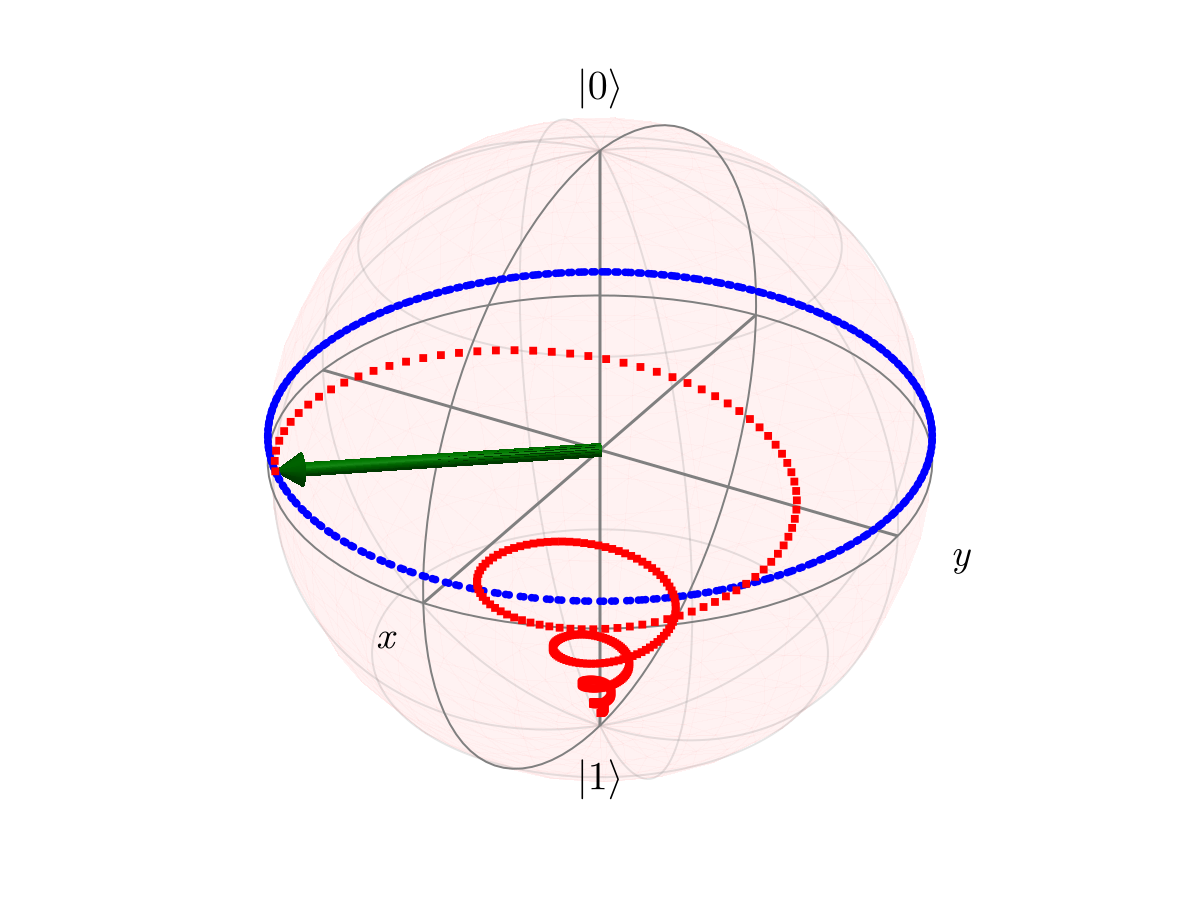

In [9]:
b_me = Bloch() # create an empty Bloch sphere

add_states!(b_me, ψ0) # initial state

# ideal precession (sesolve)
add_points!(b_me, [real(sol_se.expect[1, :]), real(sol_se.expect[2, :]), real(sol_se.expect[3, :])])

# precession with decay (mesolve)
add_points!(b_me, [real(sol_me.expect[1, :]), real(sol_me.expect[2, :]), real(sol_me.expect[3, :])])

# render and show Bloch sphere
fig, _ = render(b_me)
fig

## Precession around a general axis

For a field pointing along an arbitrary direction $\hat{n}$, the Hamiltonian is

```math
\hat{H} = -\frac{\omega_0}{2}\hat{n}\cdot\vec{\sigma},
```

and the Bloch vector precesses on a cone around $\hat{n}$ instead of around $\hat{z}$. For example, we consider $\hat{n} = (\sin\theta, 0, \cos\theta)$, and thus, the Hamiltonian is

```math
\hat{H} = -\frac{\omega_0}{2}\left(\sin\theta\,\hat{\sigma}_x + \cos\theta\,\hat{\sigma}_z\right)
```


In [10]:
θ = 0.2π

H_n = -0.5 * ω0 * (sin(θ) * σx + cos(θ) * σz)

ψ0_n = basis(2, 0) # initial state |0⟩

tlist_n = range(0, 30, 400)

sol_se_n = sesolve(H_n, ψ0_n, tlist_n; e_ops = e_ops)

γe = 0.2   # energy relaxation rate
γϕ = 0.1   #  pure  dephasing  rate
c_ops = [sqrt(γe) * sigmam(), sqrt(γϕ) * σz]
sol_me_n = mesolve(H_n, ψ0_n, tlist_n, c_ops; e_ops = e_ops);

[sesolve] 100%|███████████████████████████| Time: 0:00:00 ( 0.63 μs/it)
[mesolve] 100%|███████████████████████████| Time: 0:00:00 ( 0.32 μs/it)


┌ Warning: Arrows3D{Tuple{Vector{Point{3, Float32}}, Vector{Point{3, Float32}}}} is not supported by cairo right now
└ @ CairoMakie /opt/julia/packages/CairoMakie/M4iiC/src/plot-primitives.jl:191
┌ Warning: Arrows3D{Tuple{Vector{Point{3, Float32}}, Vector{Point{3, Float32}}}} is not supported by cairo right now
└ @ CairoMakie /opt/julia/packages/CairoMakie/M4iiC/src/plot-primitives.jl:191


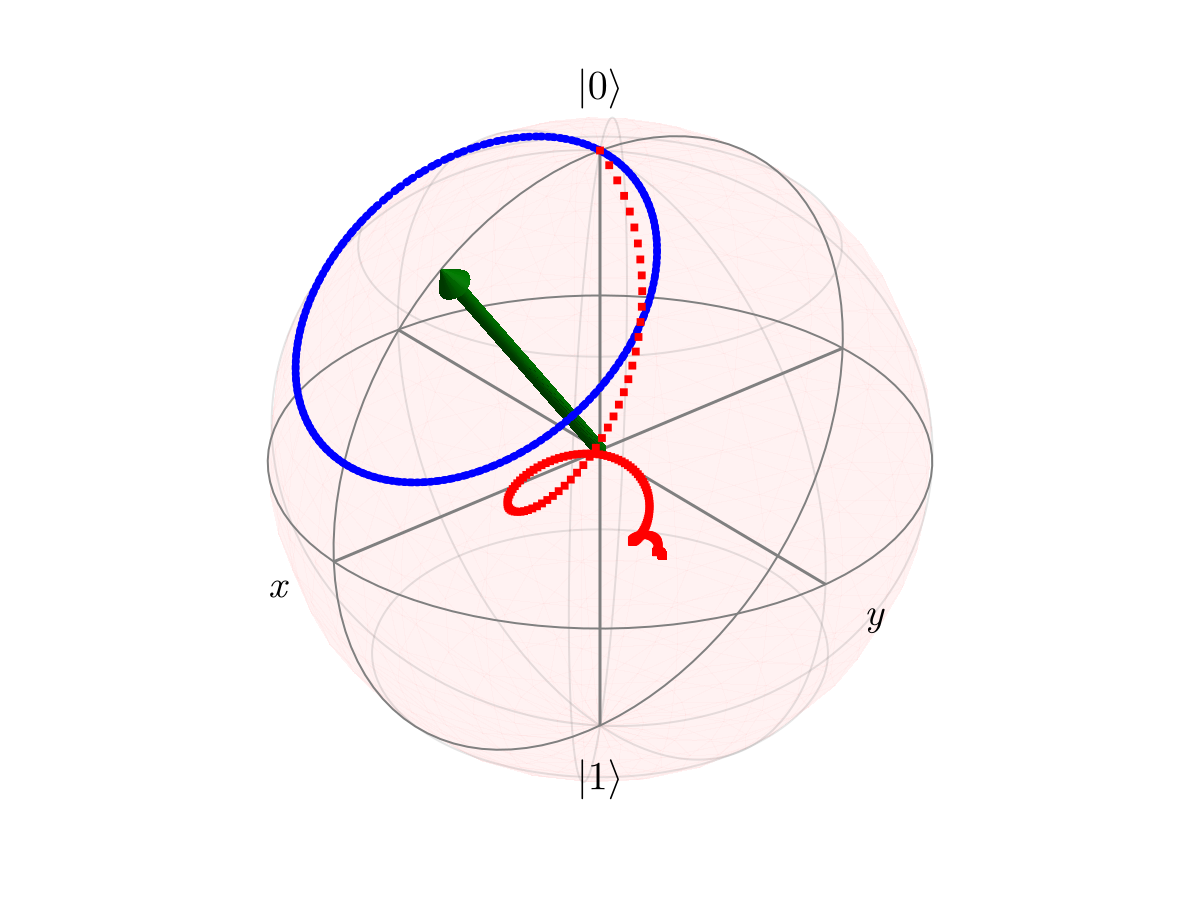

In [11]:
b_n = Bloch()      # create an empty Bloch sphere
b_n.view = [50,30] # change the view angle of Bloch sphere

add_vectors!(b_n, [sin(θ), 0, cos(θ)]) # precession axis ̂n

# ideal precession (sesolve)
add_points!(b_n, [real(sol_se_n.expect[1, :]), real(sol_se_n.expect[2, :]), real(sol_se_n.expect[3, :])])

# precession with decay (mesolve)
add_points!(b_n, [real(sol_me_n.expect[1, :]), real(sol_me_n.expect[2, :]), real(sol_me_n.expect[3, :])])

# render and show Bloch sphere
fig, _ = render(b_n)
fig

The green arrow now indicates the precession axis $\hat{n}$, and the initial state $|\psi_0\rangle = |0\rangle$. In this case, the Bloch vector sweeps out a cone around $\hat{n}$ rather than a latitude circle around $\hat{z}$.

With dissipation defined in $Z$-basis, the relaxation axis is not generally aligned with the precession axis ($\hat{n}$). The trajectory approaches a steady state determined by both Hamiltonian ($\hat{H}$) and the collapse operators ($\sqrt{\gamma_e}\hat{\sigma}_-$ and $\sqrt{\gamma_\varphi}\hat{\sigma}_z$).

## Time-dependent field: `QobjEvo`

So far the field direction and magnitude were both fixed. Now suppose only the field *magnitude* oscillates in time while its direction stays along $\hat z$, e.g., $B_0(t) = B_0\left[1 + \varepsilon\sin(\Omega t)\right]$. The corresponding Larmor frequency $\omega(t) = \omega_0\left[1 + \varepsilon\sin(\Omega t)\right]$ is no longer constant, so the Hamiltonian becomes time-dependent:

```math
\hat{H}(t) = -\frac{\omega(t)}{2}\hat{\sigma}_z
```

Since the field direction never changes, $\langle\hat\sigma_z\rangle$ is still conserved; only the *rate* at which the transverse components precess speeds up and slows down.

By using `QobjEvo` we can pass the parameters ($\omega_0$, $\varepsilon$, $\Omega$) into `sesolve` via the keyword argument `params`.

In [12]:
# ε: modulation depth, Ω: modulation frequency
coef(p, t) = -0.5 * p.ω0 * (1 + p.ε * sin(p.Ω * t))

H_t = QobjEvo(σz, coef)

p = (ω0 = ω0, ε = 0.5, Ω = 0.3)
sol_t = sesolve(H_t, ψ0, tlist; e_ops = e_ops, params = p)

[sesolve] 100%|███████████████████████████| Time: 0:00:00 ( 1.26 μs/it)


Solution of time evolution
(return code: Success)
--------------------------
num_states = 1
num_expect = 3
ODE alg.: OrdinaryDiffEqVerner.Vern7{typeof(OrdinaryDiffEqCore.trivial_limiter!), typeof(OrdinaryDiffEqCore.trivial_limiter!), FastBroadcast.Serial, Bool}(OrdinaryDiffEqCore.trivial_limiter!, OrdinaryDiffEqCore.trivial_limiter!, FastBroadcast.Serial(), false)
abstol = 1.0e-8
reltol = 1.0e-6


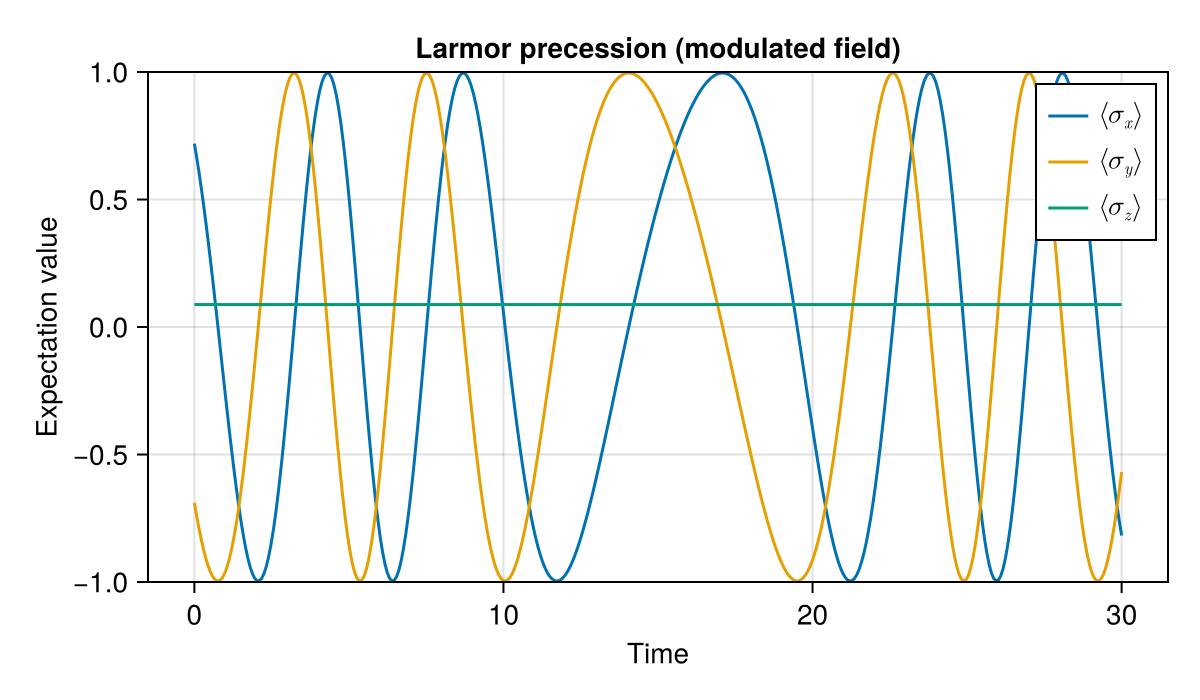

In [13]:
fig = Figure(size = (600, 350))
ax = Axis(
    fig[1, 1],
    xlabel = "Time",
    ylabel = "Expectation value",
    title = "Larmor precession (modulated field)",
    limits = (nothing, nothing, -1, 1),
)

lines!(ax, tlist, real(sol_t.expect[1, :]), label = L"\langle\sigma_x\rangle")
lines!(ax, tlist, real(sol_t.expect[2, :]), label = L"\langle\sigma_y\rangle")
lines!(ax, tlist, real(sol_t.expect[3, :]), label = L"\langle\sigma_z\rangle")
axislegend(ax, position = :rt)

fig

The precession rate now visibly speeds up and slows down as $\omega(t)$ oscillates.

$\langle\hat{\sigma}_z(t)\rangle$ is still conserved, since the field direction ($\hat{z}$) never changes, only its magnitude does.

Overall, on the Bloch sphere, the trajectory still traces the same latitude circle as before, just at a non-uniform angular speed.